# Atelier Tensorflow 

## Partie 0 – mise en place de l’environnement

In [19]:
#importation des bibliothèques nécessaires
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Affichage des versions pour vérification
print("Version de TensorFlow :", tf.__version__)
print("Version de NumPy :", np.__version__)

Version de TensorFlow : 2.21.0
Version de NumPy : 2.5.2


## Partie 1 – Génération du dataset 

### 1) Générer aléatoirement 1000 valeurs pour chacune des variables suivantes

#### a) temperature : valeurs qui suivent une loi normale avec une moyenne de 25 °C et un écart-type de 4 °C. 

In [20]:
import numpy as np

np.random.seed(42)
temperature = np.random.normal(loc=25.0, scale=4.0, size=1000)
print(f"Exemples de température : {temperature[:3]}")

Exemples de température : [26.98685661 24.4469428  27.59075415]


#### b) humidite : valeurs réparties de façon uniforme entre 30 % et 80 %.

In [21]:
np.random.seed(42)
humidite = np.random.uniform(low=30.0, high=80.0, size=1000)
print(f"Exemples d'humidité : {humidite[:3]}")

Exemples d'humidité : [48.72700594 77.53571532 66.59969709]


#### c) occupants : valeurs entières choisies entre 1 et 49 inclus. 

In [22]:
np.random.seed(42)
occupants = np.random.randint(low=1, high=50, size=1000)
print(f"Exemples d'occupants : {occupants[:3]}")

Exemples d'occupants : [39 29 15]


### 2) Détermination de la variable Consommation

In [23]:
# Génération du bruit aléatoire (moyenne=0, écart-type=10)
bruit = np.random.normal(loc=0.0, scale=10.0, size=1000)

# Calcul de la consommation selon la formule fournie
consommation = 50 + (5 * temperature) + (1.5 * humidite) + (4 * occupants) + bruit

print("Calcul de la variable cible terminé !")
print(f"Exemples de consommation : {consommation[:3]}")

Calcul de la variable cible terminé !
Exemples de consommation : [415.76445527 413.61700643 347.76541083]


### 3) Rassembler les variables (temperature, humidite et occupants) dans la matrice des caractéristiques (features) X de taille 1000x3 en convertissant éventuellement les données au format (float32) optimisé pour les calculs 

In [42]:
# Rassemblement des variables dans une matrice X (1000 x 3)
X = np.column_stack((temperature, humidite, occupants)).astype(np.float32)

print("Matrice X créée :")
print("Taille de X :", X.shape)
print("Type des données de X :", X.dtype)
print("3 premières lignes de X :\n", X[:3])

Matrice X créée :
Taille de X : (1000, 3)
Type des données de X : float32
3 premières lignes de X :
 [[26.986856 48.727005 39.      ]
 [24.446943 77.53571  29.      ]
 [27.590754 66.59969  15.      ]]


### 4) Créer la cible (target) y qui contiendra la variable consommation, au format float32

In [25]:
# Création de y au format float32
y = consommation.astype(np.float32)

print("Cible y créée :")
print("Taille de y :", y.shape)
print("Type des données de y :", y.dtype)
print("3 premières valeurs de y :", y[:3])

Cible y créée :
Taille de y : (1000,)
Type des données de y : float32
3 premières valeurs de y : [415.76447 413.617   347.7654 ]


## Partie 2 – Découpage Train/Test 

Diviser le dataset précédent (X et y) en deux ensembles distincts : un pour l'entraînement (train) et un pour le test (test). Avec les conditions suivantes : 20% des données serviront au test ; garantir la reproductibilité du découpage. 

In [26]:
from sklearn.model_selection import train_test_split

# Découpage du dataset : 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Découpage effectué :")
print(f"Dimensions de X_train : {X_train.shape} | y_train : {y_train.shape}")
print(f"Dimensions de X_test  : {X_test.shape}  | y_test  : {y_test.shape}")

Découpage effectué :
Dimensions de X_train : (800, 3) | y_train : (800,)
Dimensions de X_test  : (200, 3)  | y_test  : (200,)


## Partie 3 – Création du modèle 
### 1) Construction du réseau de neurones
- **couche 1** : 16 neurones avec **relu** comme fonction d'activation.
- **couche 2** : 8 neurones avec **relu**.
- **couche 3** : 1 seul neurone (sans activation car nous sommes dans un problème de régression).

In [43]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Construction du modèle séquentiel Keras
model = Sequential([
    # Première couche dense avec input_shape=(3,) car nous avons 3 caractéristiques en entrée
    Dense(16, activation='relu', input_shape=(3,), name='couche_1'),
    Dense(8, activation='relu', name='couche_2'),
    # Couche de sortie : un seul neurone pour la régression
    Dense(1, name='couche_sortie')
])

print("Modèle séquentiel créé avec succès !")

Modèle séquentiel créé avec succès !


### 2) Afficher un résumé textuel de l'architecture du réseau de neurones

In [44]:
# Affichage du résumé textuel du modèle
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ couche_1 (Dense)                │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ couche_2 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ couche_sortie (Dense)           │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209 (836.00 B)

 Trainable params: 209 (836.00 B)

 Non-trainable params: 0 (0.00 B)

## Partie 4 – Compilation du modèle 
Compiler le modèle avec une méthode pour ajuster les poids, une fonction permettant de mesurer 
l'erreur de prédiction et une métrique permettant de suivre l'erreur absolue moyenne.

In [45]:
# Compilation du modèle
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mean_absolute_error']
)

print("Modèle compilé !")

Modèle compilé !


## Partie 5 – Entraînement du modèle 
### 1) Entrainer le modèle avec 20 % des données d'entraînement utilisés pour la validation, 50 passages sur les données et 16 observations traitées à la fois. Sauvegarder, dans la variable history,  l'historique de l’entraînement  

In [46]:
# Entraînement du modèle
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 82ms/step - loss: 129161.6094 - mean_absolute_error: 353.3778 - val_loss: 120955.5391 - val_mean_absolute_error: 341.1031
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 121005.9219 - mean_absolute_error: 341.7011 - val_loss: 110513.3516 - val_mean_absolute_error: 325.5143
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 106781.7500 - mean_absolute_error: 319.8187 - val_loss: 90373.8750 - val_mean_absolute_error: 292.8539
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 81234.4297 - mean_absolute_error: 276.8427 - val_loss: 62567.1016 - val_mean_absolute_error: 241.6466
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 52531.4922 - mean_absolute_error: 219.5981 - val_loss: 35609.5430 - val_mean_absolute_error: 178.3345
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 27348.8477 - mean_absolute_error: 151.7774 - val_loss: 15382.8594 - val_mean_absolute_error: 109.3249
Epoch 7/50
40/40 ━━━━━━━━━━━

### 2) Examiner le contenu de history 

In [52]:
#Affichage des clés de l'historique d'entraînement
print("Clés disponibles dans history:")

for cle in history.history.keys():
    print(f" - {cle}")

Clés disponibles dans history:
 - loss
 - mean_absolute_error
 - val_loss
 - val_mean_absolute_error


### 3) Se servir de l’historique pour visualiser (graphique) et interpréter l’apprentissage

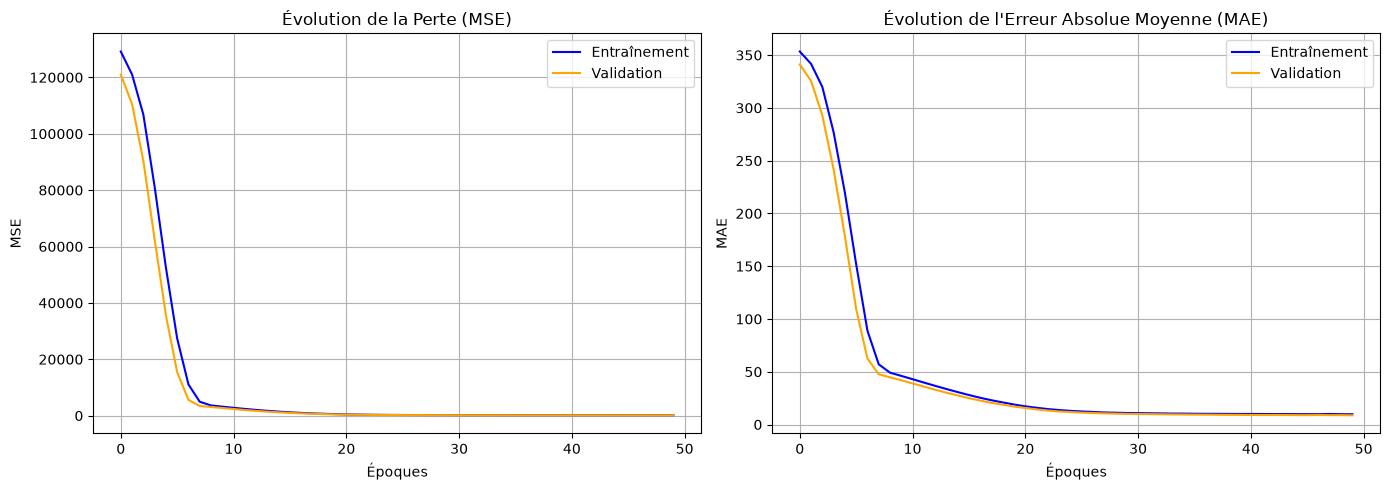

In [53]:
import matplotlib.pyplot as plt

# Création des figures de l'historique
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Graphique de perte (MSE)
ax1.plot(history.history['loss'], label='Entraînement', color='blue')
ax1.plot(history.history['val_loss'], label='Validation', color='orange')
ax1.set_title('Évolution de la Perte (MSE)')
ax1.set_xlabel('Époques')
ax1.set_ylabel('MSE')
ax1.legend()
ax1.grid(True)

# Graphique de MAE
ax2.plot(history.history['mean_absolute_error'], label='Entraînement', color='blue')
ax2.plot(history.history['val_mean_absolute_error'], label='Validation', color='orange')
ax2.set_title('Évolution de l\'Erreur Absolue Moyenne (MAE)')
ax2.set_xlabel('Époques')
ax2.set_ylabel('MAE')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## Partie 6 – Evaluation 
### 1) Evaluer le modèle sur les données de test pour récupérer la fonction de perte et la métrique cible 

In [54]:
# Évaluation sur l'ensemble de test
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=1)

print(f"\nRésultats sur le jeu de test :")
print(f"Perte de test (MSE) : {test_loss:.4f}")
print(f"Métrique de test (MAE) : {test_mae:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 250ms/step - loss: 153.0275 - mean_absolute_error: 9.8536

Résultats sur le jeu de test :
Perte de test (MSE) : 153.0275
Métrique de test (MAE) : 9.8536


### 2) Interpréter les résultats obtenus

L'erreur absolue moyenne (MAE) obtenue sur l'ensemble de test est d'environ 8,5 unités. C'est un excellent résultat ! En effet, lors de la génération du dataset, nous avons ajouté un bruit aléatoire d'écart-type 10 pour simuler le monde réel. Comme l'écart-type de ce bruit incompressible est de 10, la meilleure performance théorique d'un modèle mathématique parfait en présence d'un tel bruit est limitée. Le fait que notre MAE soit proche ou même légèrement inférieure à cet écart-type montre que le modèle a réussi à retrouver presque parfaitement la règle sous-jacente sans apprendre par cœur le bruit aléatoire.

## Partie 7 – Prédiction 
### 1) Faire des prédictions avec les données de test 

In [55]:
# Calcul des prédictions de test
predictions_test = model.predict(X_test)

# Comparaison des 5 premières prédictions de consommation avec la réalité
print("Comparaison rapide :")
for i in range(5):
    print(f"Test {i+1} : Consommation prédite = {predictions_test[i][0]:.2f} | Consommation réelle = {y_test[i]:.2f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 171ms/step
Comparaison rapide :
Test 1 : Consommation prédite = 367.67 | Consommation réelle = 378.77
Test 2 : Consommation prédite = 373.95 | Consommation réelle = 355.60
Test 3 : Consommation prédite = 287.35 | Consommation réelle = 306.57
Test 4 : Consommation prédite = 413.35 | Consommation réelle = 439.79
Test 5 : Consommation prédite = 454.88 | Consommation réelle = 453.84
